In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pathlib import Path

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)

In [9]:
def find_repo_root(start_path: Path) -> Path:
    for path in [start_path, *start_path.parents]:
        if (path / "data" / "processed").exists():
            return path
    raise FileNotFoundError("Could not locate the repository root containing data/processed")

BASE_DIR = find_repo_root(Path().resolve())
DATA_PATH = BASE_DIR / "data" / "processed"

In [10]:
performance = pd.read_csv(DATA_PATH / "clean_scheme_performance.csv")
performance.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,Sbi Bluechip Fund - Regular Plan - Growth,Sbi Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288,1.54,4,Moderate
1,119552,Sbi Bluechip Fund - Direct Plan - Growth,Sbi Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231,0.66,3,Moderate
2,119598,Sbi Small Cap Fund - Regular Plan - Growth,Sbi Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,Sbi Small Cap Fund - Direct Plan - Growth,Sbi Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
4,119120,Sbi Magnum Gilt Fund - Regular Plan - Growth,Sbi Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low


In [11]:
print(performance.shape)
performance.info()
performance.describe()

(40, 19)
<class 'pandas.DataFrame'>
RangeIndex: 40 entries, 0 to 39
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           40 non-null     int64  
 1   scheme_name         40 non-null     str    
 2   fund_house          40 non-null     str    
 3   category            40 non-null     str    
 4   plan                40 non-null     str    
 5   return_1yr_pct      40 non-null     float64
 6   return_3yr_pct      40 non-null     float64
 7   return_5yr_pct      40 non-null     float64
 8   benchmark_3yr_pct   40 non-null     float64
 9   alpha               40 non-null     float64
 10  beta                40 non-null     float64
 11  sharpe_ratio        40 non-null     float64
 12  sortino_ratio       40 non-null     float64
 13  std_dev_ann_pct     40 non-null     float64
 14  max_drawdown_pct    40 non-null     float64
 15  aum_crore           40 non-null     int64  
 16  expense_rati

,amfi_code,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating
count,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.00000,40.000000,40.000000
mean,120247.000000,14.376000,14.089000,14.516750,12.835500,1.253500,0.873250,1.361750,2.082500,14.962500,-19.200250,26091.60000,1.237000,4.250000
std,14534.998667,4.883023,4.617253,4.454021,4.740972,0.447412,0.224846,1.475805,2.203144,6.669282,8.819164,13809.11134,0.386584,0.742484
min,100016.000000,4.260000,5.140000,5.430000,3.960000,0.510000,0.220000,0.800000,1.030000,0.500000,-33.500000,979.00000,0.550000,3.000000
25%,118632.750000,11.735000,12.035000,12.340000,10.690000,0.887500,0.890000,0.865000,1.270000,14.000000,-25.062500,17400.50000,0.787500,4.000000
50%,119551.500000,14.620000,14.205000,14.185000,13.090000,1.205000,0.960000,0.925000,1.445000,14.000000,-20.600000,26713.00000,1.425000,4.000000
75%,120842.250000,16.392500,15.882500,17.585000,14.775000,1.700000,1.000000,0.985000,1.637500,19.000000,-14.255000,38125.00000,1.540000,5.000000
max,149324.000000,24.930000,23.390000,23.800000,22.160000,1.980000,1.040000,7.680000,10.370000,25.000000,-2.230000,49046.00000,1.640000,5.000000


In [12]:
performance.isnull().sum()

amfi_code             0
scheme_name           0
fund_house            0
category              0
plan                  0
return_1yr_pct        0
return_3yr_pct        0
return_5yr_pct        0
benchmark_3yr_pct     0
alpha                 0
beta                  0
sharpe_ratio          0
sortino_ratio         0
std_dev_ann_pct       0
max_drawdown_pct      0
aum_crore             0
expense_ratio_pct     0
morningstar_rating    0
risk_grade            0
dtype: int64

In [13]:
top_1yr = performance.sort_values(
    by="return_1yr_pct",
    ascending=False
).head(10)

top_1yr

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
29,101207,Absl Small Cap Fund - Regular - Growth,Aditya Birla Sun Life Mf,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,0.97,0.90,1.47,25.0,-23.61,41613,1.53,5,Very High
2,119598,Sbi Small Cap Fund - Regular Plan - Growth,Sbi Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
27,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Small Cap,Regular,21.97,20.98,22.62,20.47,0.51,1.00,0.84,1.40,25.0,-14.45,21545,1.38,4,Very High
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India Mf,Small Cap,Regular,21.30,20.15,21.88,19.35,0.80,1.03,0.81,1.14,25.0,-30.87,43630,1.53,4,Very High
3,119599,Sbi Small Cap Fund - Direct Plan - Growth,Sbi Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
39,149324,Dsp Small Cap Fund - Regular - Growth,Dsp Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,0.98,0.80,1.23,25.0,-17.01,35124,1.52,4,Very High
8,125498,Hdfc Mid-Cap Opportunities Fund - Direct - Growth,Hdfc Mutual Fund,Mid Cap,Direct,19.98,15.29,15.85,14.39,0.90,1.04,0.80,1.38,19.0,-32.22,18792,0.78,4,High
33,102887,Uti Flexi Cap Fund - Regular - Growth,Uti Mutual Fund,Flexi Cap,Regular,17.43,15.34,15.78,13.55,1.79,1.00,0.96,1.37,16.0,-12.14,17912,1.64,5,Moderately High
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra Mf,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,1.00,0.96,1.27,19.0,-21.92,47469,1.56,4,High
13,120506,Icici Pru Value Discovery Fund - Regular - Growth,Icici Prudential Mf,Value,Regular,16.67,14.76,12.60,14.21,0.55,0.92,0.98,1.50,15.0,-21.89,2571,1.41,4,Moderately High


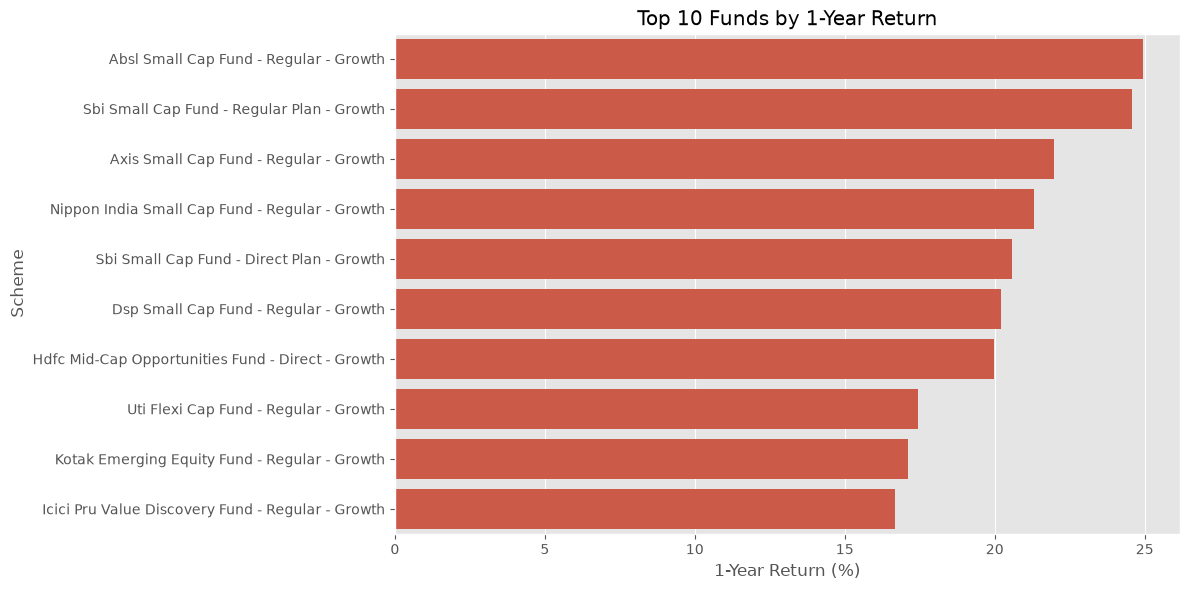

In [14]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_1yr,
    x="return_1yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 1-Year Return")
plt.xlabel("1-Year Return (%)")
plt.ylabel("Scheme")
plt.tight_layout()
plt.show()

In [15]:
top_3yr = performance.sort_values(
    by="return_3yr_pct",
    ascending=False
).head(10)

top_3yr

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
2,119598,Sbi Small Cap Fund - Regular Plan - Growth,Sbi Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259,1.43,5,Very High
3,119599,Sbi Small Cap Fund - Direct Plan - Growth,Sbi Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
29,101207,Absl Small Cap Fund - Regular - Growth,Aditya Birla Sun Life Mf,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,0.97,0.90,1.47,25.0,-23.61,41613,1.53,5,Very High
27,119095,Axis Small Cap Fund - Regular - Growth,Axis Mutual Fund,Small Cap,Regular,21.97,20.98,22.62,20.47,0.51,1.00,0.84,1.40,25.0,-14.45,21545,1.38,4,Very High
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India Mf,Small Cap,Regular,21.30,20.15,21.88,19.35,0.80,1.03,0.81,1.14,25.0,-30.87,43630,1.53,4,Very High
39,149324,Dsp Small Cap Fund - Regular - Growth,Dsp Mutual Fund,Small Cap,Regular,20.20,20.08,20.61,19.39,0.69,0.98,0.80,1.23,25.0,-17.01,35124,1.52,4,Very High
21,120842,Kotak Emerging Equity Fund - Regular - Growth,Kotak Mahindra Mf,Mid Cap,Regular,17.12,18.23,17.75,16.32,1.91,1.00,0.96,1.27,19.0,-21.92,47469,1.56,4,High
12,120505,Icici Pru Midcap Fund - Regular - Growth,Icici Prudential Mf,Mid Cap,Regular,14.02,18.08,17.55,17.19,0.89,1.00,0.95,1.45,19.0,-21.84,979,1.36,3,High
38,149323,Dsp Midcap Fund - Regular - Growth,Dsp Mutual Fund,Mid Cap,Regular,14.12,17.16,19.00,16.14,1.02,0.98,0.90,1.50,19.0,-26.99,37835,1.61,4,High
7,100033,Hdfc Mid-Cap Opportunities Fund - Regular - Gr...,Hdfc Mutual Fund,Mid Cap,Regular,15.43,16.58,17.69,15.63,0.95,0.91,0.87,1.44,19.0,-13.67,23185,1.38,5,High


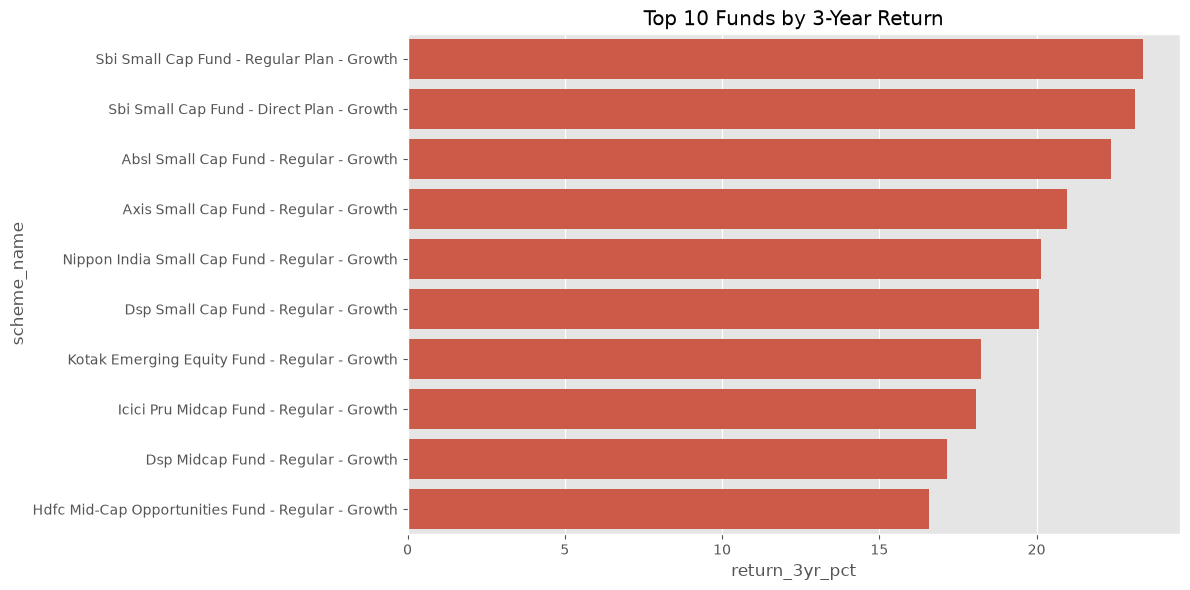

In [16]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_3yr,
    x="return_3yr_pct",
    y="scheme_name"
)

plt.title("Top 10 Funds by 3-Year Return")
plt.tight_layout()
plt.show()

In [17]:
top_sharpe = performance.sort_values(
    by="sharpe_ratio",
    ascending=False
).head(10)

top_sharpe

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
14,120507,Icici Pru Liquid Fund - Regular - Growth,Icici Prudential Mf,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra Mf,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,0.47,6.18,9.70,0.5,-3.81,27623,0.60,3,Low
30,101208,Absl Liquid Fund - Regular - Growth,Aditya Birla Sun Life Mf,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,0.43,5.14,8.76,0.5,-3.66,38995,0.79,5,Low
9,100025,Hdfc Short Term Debt Fund - Regular - Growth,Hdfc Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low
4,119120,Sbi Magnum Gilt Fund - Regular Plan - Growth,Sbi Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India Mf,Gilt,Regular,6.19,5.31,8.71,4.42,0.89,0.37,1.33,2.38,4.0,-2.23,30030,0.55,4,Low
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset Mf,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate
5,100016,Hdfc Top 100 Fund - Regular Plan - Growth,Hdfc Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate
11,120504,Icici Pru Bluechip Fund - Direct - Growth,Icici Prudential Mf,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,1.03,1.03,1.27,14.0,-26.59,41553,0.80,3,Moderate
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India Mf,Large Cap,Regular,15.84,14.00,14.70,13.14,0.86,0.88,1.00,1.68,14.0,-16.07,20909,1.51,4,Moderate


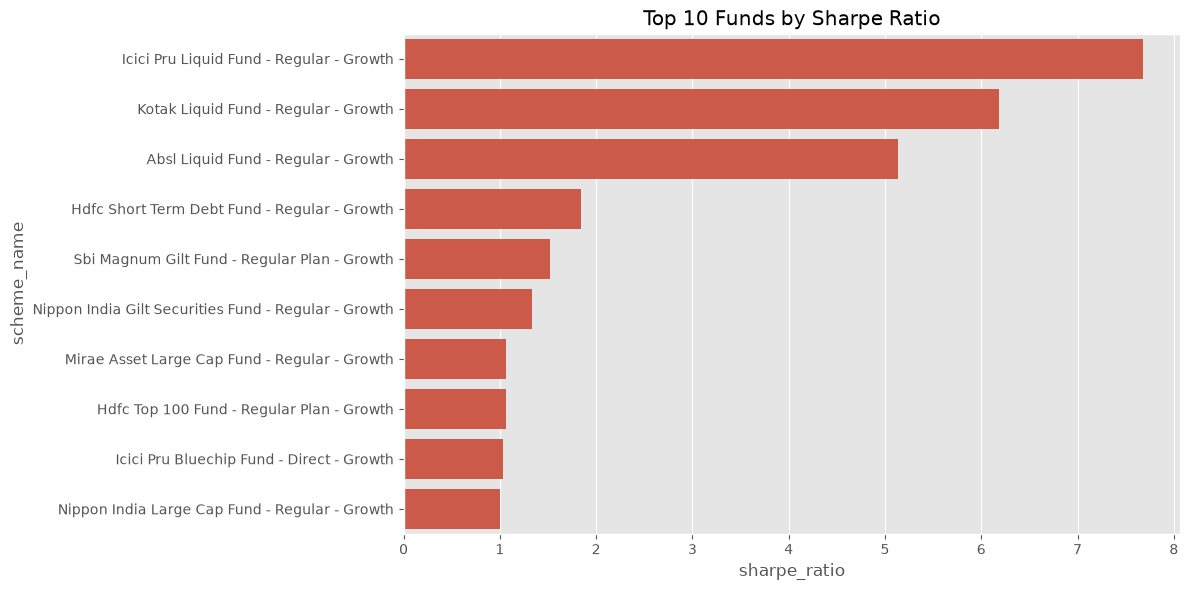

In [18]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_sharpe,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.tight_layout()
plt.show()

In [19]:
top_sortino = performance.sort_values(
    by="sortino_ratio",
    ascending=False
).head(10)

top_sortino

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
14,120507,Icici Pru Liquid Fund - Regular - Growth,Icici Prudential Mf,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra Mf,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,0.47,6.18,9.70,0.5,-3.81,27623,0.60,3,Low
30,101208,Absl Liquid Fund - Regular - Growth,Aditya Birla Sun Life Mf,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,0.43,5.14,8.76,0.5,-3.66,38995,0.79,5,Low
9,100025,Hdfc Short Term Debt Fund - Regular - Growth,Hdfc Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India Mf,Gilt,Regular,6.19,5.31,8.71,4.42,0.89,0.37,1.33,2.38,4.0,-2.23,30030,0.55,4,Low
4,119120,Sbi Magnum Gilt Fund - Regular Plan - Growth,Sbi Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low
5,100016,Hdfc Top 100 Fund - Regular Plan - Growth,Hdfc Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate
15,118632,Nippon India Large Cap Fund - Regular - Growth,Nippon India Mf,Large Cap,Regular,15.84,14.00,14.70,13.14,0.86,0.88,1.00,1.68,14.0,-16.07,20909,1.51,4,Moderate
3,119599,Sbi Small Cap Fund - Direct Plan - Growth,Sbi Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset Mf,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate


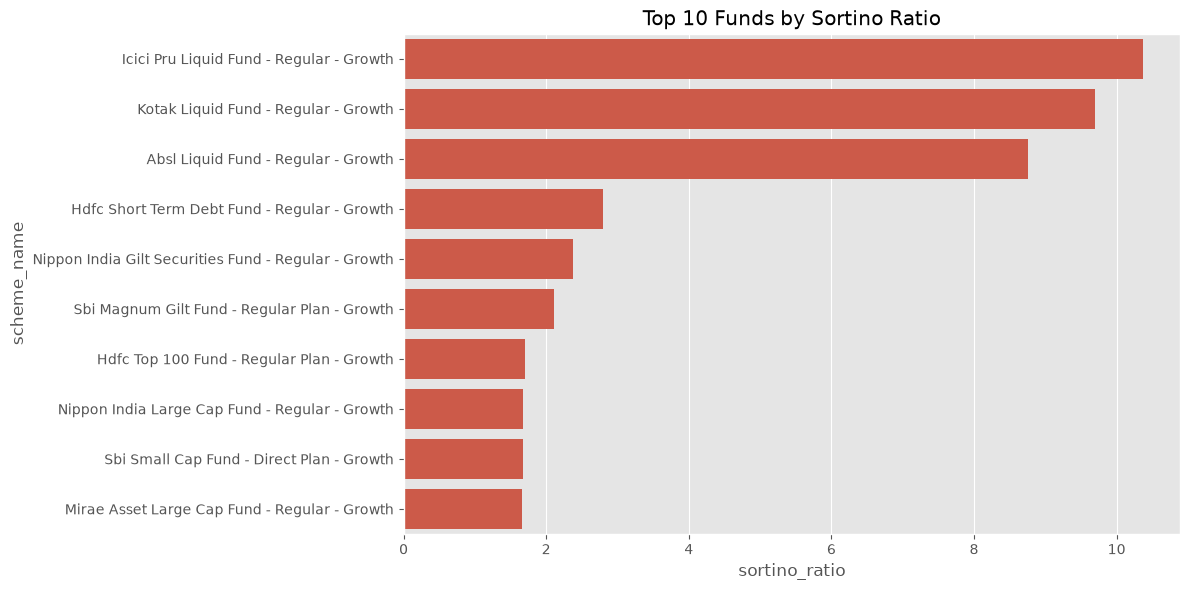

In [20]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_sortino,
    x="sortino_ratio",
    y="scheme_name"
)

plt.title("Top 10 Funds by Sortino Ratio")
plt.tight_layout()
plt.show()

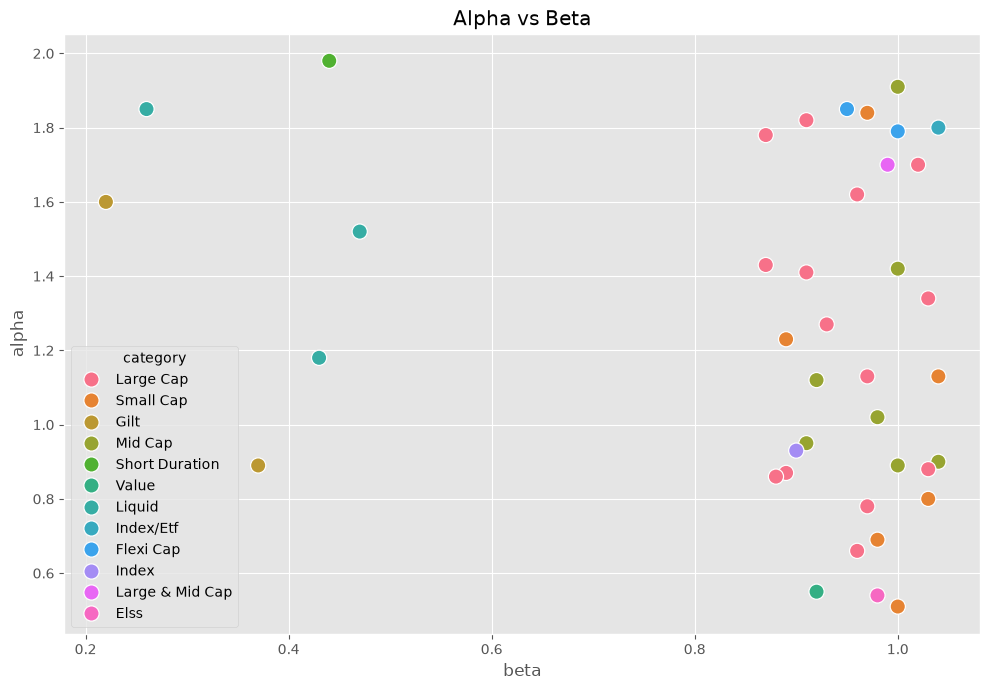

In [21]:
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=performance,
    x="beta",
    y="alpha",
    hue="category",
    s=120
)

plt.title("Alpha vs Beta")
plt.tight_layout()
plt.show()

In [22]:
worst_drawdown = performance.sort_values(
    by="max_drawdown_pct"
)

worst_drawdown.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
6,125497,Hdfc Top 100 Fund - Direct Plan - Growth,Hdfc Mutual Fund,Large Cap,Direct,11.48,13.38,13.48,12.25,1.13,0.97,0.96,1.45,14.0,-33.50,10611,0.92,4,Moderate
35,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,Mirae Asset Mf,Large & Mid Cap,Regular,14.91,14.56,15.68,12.86,1.70,0.99,0.91,1.55,16.0,-33.15,49046,1.52,5,Moderately High
26,119094,Axis Midcap Fund - Regular - Growth,Axis Mutual Fund,Mid Cap,Regular,14.88,15.18,18.94,13.76,1.42,1.00,0.80,1.18,19.0,-32.38,28996,1.38,5,High
8,125498,Hdfc Mid-Cap Opportunities Fund - Direct - Growth,Hdfc Mutual Fund,Mid Cap,Direct,19.98,15.29,15.85,14.39,0.90,1.04,0.80,1.38,19.0,-32.22,18792,0.78,4,High
17,118634,Nippon India Small Cap Fund - Regular - Growth,Nippon India Mf,Small Cap,Regular,21.30,20.15,21.88,19.35,0.80,1.03,0.81,1.14,25.0,-30.87,43630,1.53,4,Very High
24,119092,Axis Bluechip Fund - Regular - Growth,Axis Mutual Fund,Large Cap,Regular,11.82,11.84,14.14,10.43,1.41,0.91,0.85,1.25,14.0,-27.54,25803,1.64,4,Moderate
38,149323,Dsp Midcap Fund - Regular - Growth,Dsp Mutual Fund,Mid Cap,Regular,14.12,17.16,19.00,16.14,1.02,0.98,0.90,1.50,19.0,-26.99,37835,1.61,4,High
18,118635,Nippon India Etf Nifty 50 Bees,Nippon India Mf,Index/Etf,Direct,10.14,11.77,12.31,9.97,1.80,1.04,0.91,1.24,13.0,-26.75,20284,0.89,5,Moderate
11,120504,Icici Pru Bluechip Fund - Direct - Growth,Icici Prudential Mf,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,1.03,1.03,1.27,14.0,-26.59,41553,0.80,3,Moderate
10,120503,Icici Pru Bluechip Fund - Regular - Growth,Icici Prudential Mf,Large Cap,Regular,15.63,11.54,11.46,10.88,0.66,0.96,0.82,1.12,14.0,-25.91,36022,1.42,4,Moderate


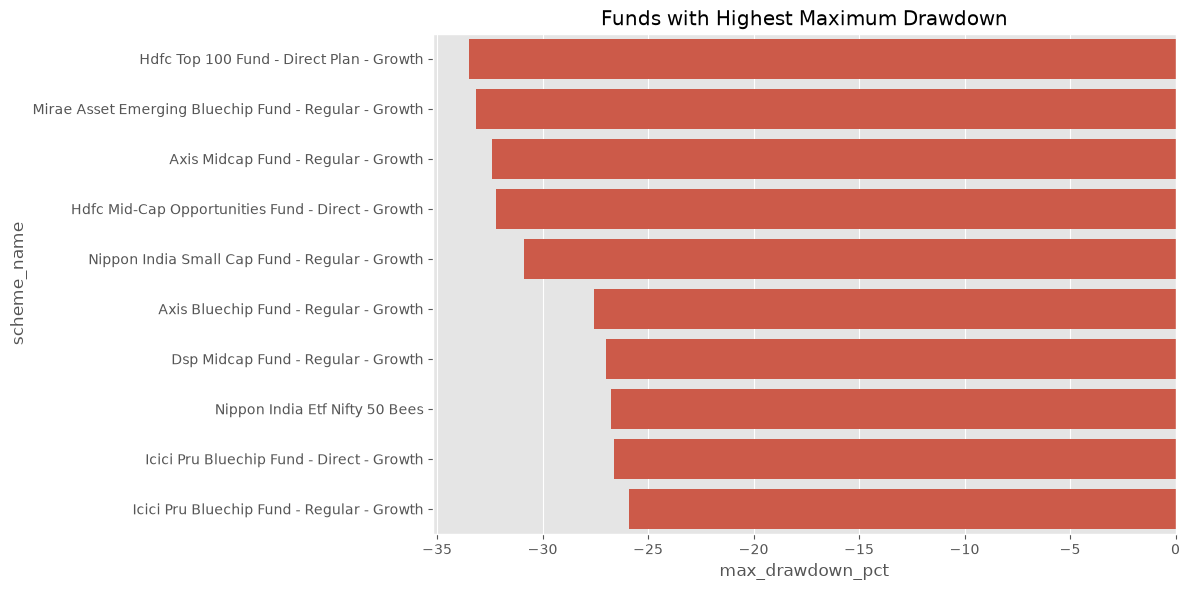

In [23]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=worst_drawdown.head(10),
    x="max_drawdown_pct",
    y="scheme_name"
)

plt.title("Funds with Highest Maximum Drawdown")
plt.tight_layout()
plt.show()

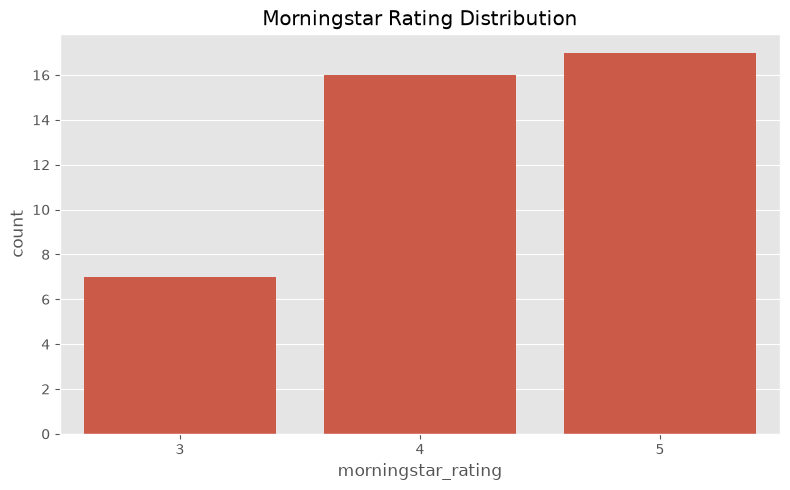

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=performance,
    x="morningstar_rating"
)

plt.title("Morningstar Rating Distribution")
plt.tight_layout()
plt.show()

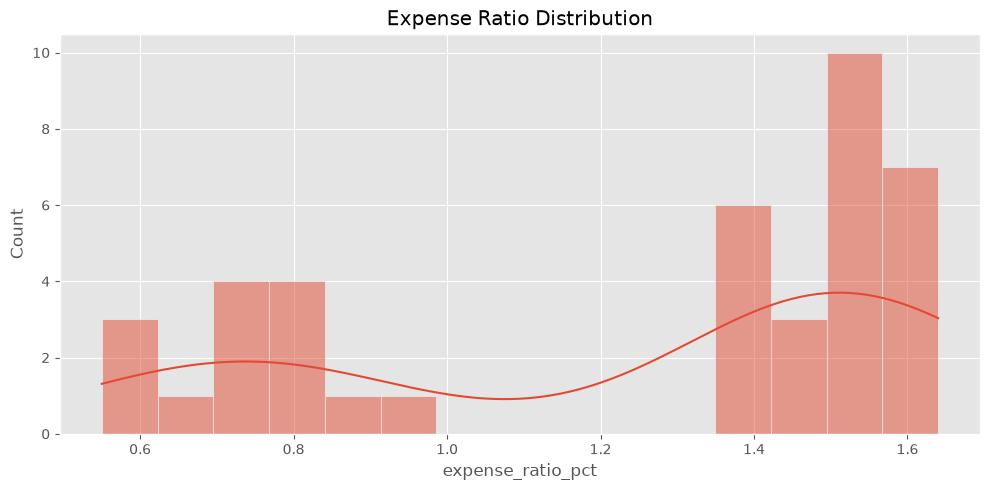

In [25]:
plt.figure(figsize=(10,5))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=15,
    kde=True
)

plt.title("Expense Ratio Distribution")
plt.tight_layout()
plt.show()

In [26]:
performance["fund_score"] = (
    performance["return_3yr_pct"] * 0.35 +
    performance["return_5yr_pct"] * 0.35 +
    performance["sharpe_ratio"] * 15 +
    performance["sortino_ratio"] * 15 -
    performance["expense_ratio_pct"] * 5
)

In [27]:
scorecard = performance.sort_values(
    by="fund_score",
    ascending=False
)

scorecard.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade,fund_score
14,120507,Icici Pru Liquid Fund - Regular - Growth,Icici Prudential Mf,Liquid,Regular,8.89,7.68,7.94,5.83,1.85,0.26,7.68,10.37,0.5,-2.62,39116,0.74,5,Low,272.5170
23,120844,Kotak Liquid Fund - Regular - Growth,Kotak Mahindra Mf,Liquid,Regular,4.26,6.18,8.26,4.66,1.52,0.47,6.18,9.70,0.5,-3.81,27623,0.60,3,Low,240.2540
30,101208,Absl Liquid Fund - Regular - Growth,Aditya Birla Sun Life Mf,Liquid,Regular,6.18,5.14,7.95,3.96,1.18,0.43,5.14,8.76,0.5,-3.66,38995,0.79,5,Low,209.1315
9,100025,Hdfc Short Term Debt Fund - Regular - Growth,Hdfc Mutual Fund,Short Duration,Regular,6.83,7.37,6.41,5.39,1.98,0.44,1.84,2.79,4.0,-6.01,27953,0.56,3,Low,71.4730
19,118636,Nippon India Gilt Securities Fund - Regular - ...,Nippon India Mf,Gilt,Regular,6.19,5.31,8.71,4.42,0.89,0.37,1.33,2.38,4.0,-2.23,30030,0.55,4,Low,57.8070
4,119120,Sbi Magnum Gilt Fund - Regular Plan - Growth,Sbi Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101,0.77,5,Low,54.6250
3,119599,Sbi Small Cap Fund - Direct Plan - Growth,Sbi Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061,0.72,4,Very High,51.1360
29,101207,Absl Small Cap Fund - Regular - Growth,Aditya Birla Sun Life Mf,Small Cap,Regular,24.93,22.38,23.80,20.54,1.84,0.97,0.90,1.47,25.0,-23.61,41613,1.53,5,Very High,44.0630
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset Mf,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate,43.1215
5,100016,Hdfc Top 100 Fund - Regular Plan - Growth,Hdfc Mutual Fund,Large Cap,Regular,10.94,14.84,11.32,14.06,0.78,0.97,1.06,1.70,14.0,-17.41,6434,1.55,5,Moderate,42.8060


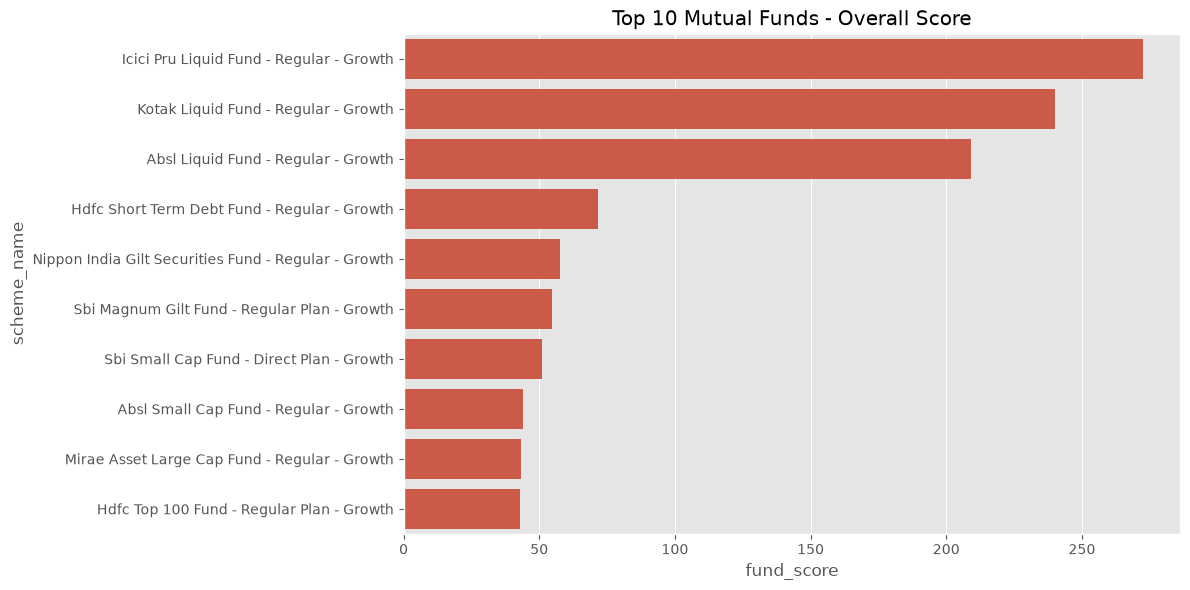

In [28]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=scorecard.head(10),
    x="fund_score",
    y="scheme_name"
)

plt.title("Top 10 Mutual Funds - Overall Score")
plt.tight_layout()
plt.show()

In [29]:
REPORT_PATH = BASE_DIR.parent / "reports"
REPORT_PATH.mkdir(exist_ok=True)
scorecard.to_csv(
    REPORT_PATH / "fund_scorecard.csv",
    index=False
)
print("Fund scorecard saved successfully!")

Fund scorecard saved successfully!
